# Supervised Learning Algorithms

# KNN

# Naive Bayes

# Decision Tree

# Support Vector Machine (SVM)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.drop(['who', 'embark_town', 'deck', 'embark_town',
       'alive', 'class', 'adult_male'], axis=1, inplace=True)

In [6]:
df['age'].fillna(df['age'].mean(), inplace=True)

In [7]:
# as embarked has 889 not null rows, we are dropping 2 rows from the dataset

df.dropna(subset=['embarked'], inplace=True)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [9]:
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

In [10]:
df = df.astype(int)

In [11]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1


In [12]:
X = df.drop('survived', axis=1)
y = df['survived']

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [14]:
X_scaled = scaler.fit_transform(X)

In [15]:
X_scaled

array([[ 0.82520863,  0.73534203, -0.57802333, ..., -0.49673282,
         0.58683958, -1.22934919],
       [-1.57221121, -1.35991138,  0.65537059, ...,  0.79153916,
        -1.93955453, -1.22934919],
       [ 0.82520863, -1.35991138, -0.26967485, ..., -0.49673282,
         0.58683958,  0.81343853],
       ...,
       [ 0.82520863, -1.35991138, -0.03841349, ..., -0.17466483,
         0.58683958, -1.22934919],
       [-1.57221121,  0.73534203, -0.26967485, ..., -0.03376008,
        -1.93955453,  0.81343853],
       [ 0.82520863,  0.73534203,  0.19284787, ..., -0.49673282,
        -0.67635748,  0.81343853]])

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [18]:
y_pred = model.predict(X_test)

In [19]:
# Model Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
accu_sc = accuracy_score(y_test, y_pred)
accu_sc

0.797752808988764

In [21]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[89, 20],
       [16, 53]])

<Axes: >

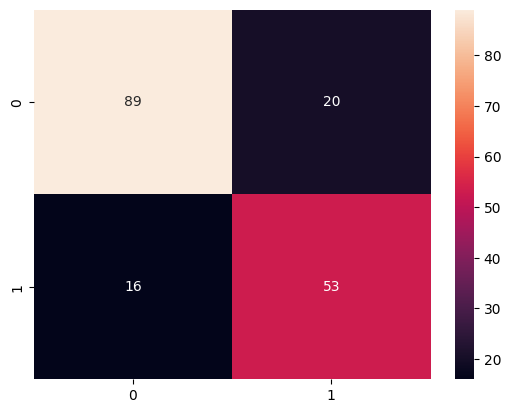

In [22]:
sns.heatmap(cm, annot=True, fmt='d')


In [23]:
clsf_report = classification_report(y_test, y_pred)
print(clsf_report)

              precision    recall  f1-score   support

           0       0.85      0.82      0.83       109
           1       0.73      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



# Naive Bayes

Naive Bayes is a fast, efficient supervised machine learning algorithm for classification based on Bayes' Theorem, which predicts class probabilities by assuming independence between features

In [24]:
X2 = df.drop('survived', axis=1)
y2 = df['survived']

In [25]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [26]:
from sklearn.naive_bayes import GaussianNB

model2 = GaussianNB()
model2.fit(X2_train, y2_train)

GaussianNB()

In [27]:
y2_pred = model2.predict(X2_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [29]:
accu_sc = accuracy_score(y2_test, y2_pred)
accu_sc

0.7752808988764045

In [30]:
class_report = classification_report(y2_test, y2_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       109
           1       0.68      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178



In [31]:
cm = confusion_matrix(y2_test, y2_pred)
cm

array([[84, 25],
       [15, 54]])

# Decision Tree

A decision tree classifier is a supervised machine learning algorithm that uses a flowchart-like tree structure to classify data based on a series of feature-based rules. It works by recursively splitting a dataset into smaller subsets until each subset is sufficiently "pure" (contains items belonging mostly to the same class), at which point a final decision can be made at a leaf node.

In [33]:
# We will be using scaled data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.tree import DecisionTreeClassifier

model3 = DecisionTreeClassifier(random_state=42)

In [34]:
model3.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [35]:
y_pred = model3.predict(X_test)

In [36]:
accur_scr = accuracy_score(y_test, y_pred)
accur_scr

0.8033707865168539

In [37]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[89, 20],
       [15, 54]])

<Axes: >

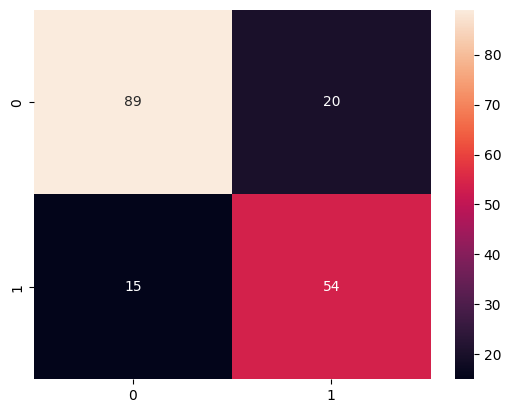

In [38]:
sns.heatmap(cm, annot=True, fmt='d')

In [40]:
classf_report = classification_report(y_test, y_pred)
print(classf_report)

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       109
           1       0.73      0.78      0.76        69

    accuracy                           0.80       178
   macro avg       0.79      0.80      0.80       178
weighted avg       0.81      0.80      0.80       178



# Support Vector Machine (SVM)

Support Vector Machine (SVM) is a powerful supervised machine learning algorithm used for classification and regression tasks by finding the optimal hyperplane that maximizes the margin between data classes. It is effective for linear and non-linear data using the "kernel trick" to map data into higher-dimensional spaces.

In [43]:
from sklearn.svm import SVC

In [44]:
model_svm = SVC(kernel='rbf')
model_svm.fit(X_train, y_train)

SVC()

In [46]:
y_pred_scm = model_svm.predict(X_test)

In [47]:
accu_sc = accuracy_score(y_test, y_pred_scm)
accu_sc

0.8146067415730337

In [48]:
cm = confusion_matrix(y_test, y_pred_scm)
cm

array([[91, 18],
       [15, 54]])

<Axes: >

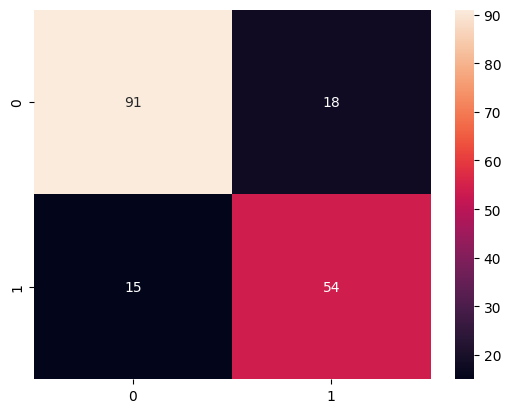

In [49]:
sns.heatmap(cm, annot=True, fmt='d')

In [50]:
classf_report = classification_report(y_test, y_pred_scm)
print(classf_report)

              precision    recall  f1-score   support

           0       0.86      0.83      0.85       109
           1       0.75      0.78      0.77        69

    accuracy                           0.81       178
   macro avg       0.80      0.81      0.81       178
weighted avg       0.82      0.81      0.82       178

